In [1]:
import os
import glob
import json
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as cl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
from collections import defaultdict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    f1_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
)

In [2]:
def h5_to_dict(h5_path):
    data = defaultdict(dict)
    with h5py.File(h5_path, 'r') as f:
        data['start_time'] = f.attrs['start_time']

        if 'ahi' in f.attrs.keys():
            data['ahi'] = f.attrs['ahi']
        
        if np.any([f'{stage}_hours' in f.attrs.keys() for stage in ['wake', 'n1', 'n2', 'n3', 'rem']]):
            stages = {
                'wake': 0,
                'n1': 0,
                'n2': 0,
                'n3': 0,
                'rem': 0,
                'missing': 0,
            }

            for stage in stages.keys():
                if f'{stage}_hours' in f.attrs.keys():
                    stages[stage] = f.attrs[f'{stage}_hours']
            data['stages_hours'] = stages
        
        data['accelerometry'] = np.array(f['data/accelerometry'])
        data['hypnogram'] = np.array(f['annotations/hypnogram'])

    return data

def safe_cw_auc(targets, scores, mode = 'ovo', count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)
    unique_targets = unique_targets[counts > count_lim]
    cw_auc = np.full(scores.shape[-1], np.nan)
    if len(unique_targets) == 1:
        return cw_auc
    for k in unique_targets:
        if mode == 'ovo':
            cw_auc[k] = 0
            for l in unique_targets:
                if l == k: continue
                tmp_mask = np.logical_or(targets == k, targets == l)
                tmp_targets = targets[tmp_mask]
                tmp_scores = scores[tmp_mask, k]
                cw_auc_kvl = roc_auc_score(tmp_targets == k,tmp_scores)
                cw_auc[k] += cw_auc_kvl/(len(unique_targets -1))
        elif mode == 'ovr':
            cw_auc[k] = roc_auc_score(targets == k, scores[:, k])
        else:
            raise "Mode must be ovo or ovr"
    return cw_auc

def safe_cw_pr_re_f1(targets, preds, num_classes, count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)

    # Target count filter
    count_filt = np.full(num_classes, np.nan)
    count_filt[unique_targets[counts > count_lim]] = 1 

    # Calculate scores (results will only include present targets)
    cw_prec = precision_score(targets, preds, average=None, zero_division=np.nan)
    cw_rec = recall_score(targets, preds, average=None, zero_division=np.nan)
    cw_f1 = f1_score(targets, preds, average=None, zero_division=np.nan)

    # Initialize NaN arrays to fill to make sure all possible targets are representet
    cw_prec_array = np.full(num_classes, np.nan)
    cw_rec_array = np.full(num_classes, np.nan)
    cw_f1_array = np.full(num_classes, np.nan)

    # Fill in NaN arrays
    for i, k in enumerate(unique_targets):
        cw_prec_array[k] = cw_prec[i] * count_filt[i]
        cw_rec_array[k] = cw_rec[i] * count_filt[i]
        cw_f1_array[k] = cw_f1[i] * count_filt[i]

    return cw_prec_array, cw_rec_array, cw_f1_array

def calc_sleep_summary_metrics(stages, label_map):
    metrics = {}
    # Calculate TST
    sleep = stages != label_map['wake']
    tst = (sleep).sum()
    metrics['tst'] = float(tst)
    
    try:
        # Calculate SOL (first consecutive 3-epoch sleep window)
        # [[sleep, False, False],
        # [False, sleep, False],
        # [False, False, sleep]]
        sleep_shifted = np.stack([
            np.append(sleep, [False, False]),
            np.insert(np.append(sleep, [False]), 0, [False]),
            np.insert(sleep, 0, [False, False]),
        ])
        sol = np.argwhere(sleep_shifted.all(axis=0)).min()
        metrics['sol'] = float(sol)

        # Calculate WASO, how to handle missing?
        # Trim back from the last index if it is wake
        # Find last index of sleep 
        last_sleep = np.argwhere(stages != label_map['wake']).max() + 1
        waso = (stages[sol: last_sleep] == label_map['wake']).sum()
        metrics['waso'] = float(waso)
    except:
        metrics['sol'] = np.nan
        metrics['waso'] = np.nan
    # Calculate SE
    # se = (stages[sol: last_sleep] != label_map['wake']).sum() / (last_sleep - sol)
    se = (stages != label_map['wake']).sum() / len(stages)
    metrics['se'] = float(se)

    # Calculate REM
    rem = (stages == ss_label_map['rem']).sum()
    metrics['rem'] = float(rem)
    
    # Calculate Deep
    deep = (stages == ss_label_map['deep']).sum()
    metrics['deep'] = float(deep)

    # Calculate Light
    light = (stages == ss_label_map['light']).sum()
    metrics['light'] = float(light)

    # Calculate NREM
    nrem = light + deep
    metrics['nrem'] = float(nrem)

    return metrics


In [3]:
ss_labels_name = 'light_deep_rem'
ss_label_map = {
    'deep': 0,
    'light': 1,
    'rem': 2,
    'wake': 3,
    'missing': -9,
}
# ss_label_map_inv = {val: key for key, val in ss_label_map.items()}
ss_label_map_inv = {val: key for key, val in ss_label_map.items() if val != -9}
ss_label_order = ['wake', 'light', 'deep', 'rem']
ss_label_name = ['Wake', 'Light', 'Deep', 'REM']

nrem_label_name = ['Wake', 'NREM', 'REM']
rem_nrem_label_map = {
    'NREM': 0,
    'REM': 1,
    'Wake': 2,
    'missing': -9,
}
rem_nrem_label_map_inv = {val: key for key, val in rem_nrem_label_map.items() if val != -9}

sleep_label_name = ['Wake', 'Sleep']
sleep_label_map = {
    'Sleep': 0,
    'Wake': 1,
    'missing': -9,
}
sleep_label_map_inv = {val: key for key, val in sleep_label_map.items() if val != -9}

ss_colormap = {
    'wake': 'tab:red',
    'Wake': 'tab:red',
    'light': 'tab:orange',
    'Light': 'tab:orange',
    'deep': 'tab:blue',
    'Deep': 'tab:blue',
    'rem': 'tab:green',
    'REM': 'tab:green',
}
ss_case_map = {
    'wake':'Wake',
    'light': 'Light',
    'deep': 'Deep',
    'rem': 'REM',
}

dset_map = {
    'newcastle_left': 'Newcastle',
    'newcastle_right': 'Newcastle',
    'stages': 'STAGES',
    'dreamt': 'DREAMT',
    'tbi': 'TBI',
    'amazfit': 'Health',
    'sleepaccel': 'SleepAccel',
}

In [12]:
## Subject-wise performance metrics
cw_precs = defaultdict(list)
cw_recalls = defaultdict(list)
cw_f1s = defaultdict(list)
cw_aucs = defaultdict(list)
roc_curves = defaultdict(list)
macro_results = defaultdict(list)
soft_preds_all = []
targets_all = []
preds_all = []

summary_diffs = defaultdict(list)
summary_means = defaultdict(list)

cw_precs_nrem = defaultdict(list)
cw_recalls_nrem = defaultdict(list)
cw_f1s_nrem = defaultdict(list)
macro_results_nrem = defaultdict(list)
soft_preds_all_nrem = []
targets_all_nrem = []
preds_all_nrem = []

cw_precs_sleep = defaultdict(list)
cw_recalls_sleep = defaultdict(list)
cw_f1s_sleep = defaultdict(list)
macro_results_sleep = defaultdict(list)

exp_i = []
subject_i = []
dataset_i = []
lin_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_internal'
lstmc_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_internal'
# lin_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_external'
# lstmc_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_external'
# lin_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_external_2'
# lstmc_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_external_2'
# lin_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_tp/tp_1.0'
# lstmc_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_tp/tp_1.0'
experiments = [('Linear', lin_path), ('LSTM-C', lstmc_path)]
for exp_name, experiment_dir in experiments:
    for dataset in os.scandir(experiment_dir):
        for sub_dir in os.scandir(dataset):
            subject_i.append(os.path.basename(sub_dir))
            dataset_i.append(os.path.basename(dataset))
            exp_i.append(exp_name)

            missing_idx = ss_label_map['missing']

            scores = np.load(os.path.join(sub_dir.path + '/soft_preds.npy'))
            targets = np.load(os.path.join(sub_dir.path + '/targets.npy'))

            scores = scores[targets != missing_idx]
            targets = targets[targets != missing_idx]

            # Excluded NaNs due to signal dropout in AccelSleep
            nan_mask = np.isnan(scores).any(-1)
            scores = scores[~nan_mask]
            targets = targets[~nan_mask]

            # Get hard predictions
            preds = scores.argmax(axis=-1)

            soft_preds_all.append(np.copy(scores))
            targets_all.append(np.copy(targets))
            preds_all.append(np.copy(preds))
 
            unique_targets, counts = np.unique(targets, return_counts=True)
            unique_preds, pred_counts = np.unique(preds, return_counts=True)
       
            ## Subject-wise class-wise scores
            # Precision, Recall, and F1
            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=scores.shape[-1], count_lim=3)
            
            # Manually compute binary AUC for each label present (NaN for non-valid)
            cw_auc = safe_cw_auc(targets, scores, mode='ovr', count_lim=3)

            for k in range(scores.shape[-1]):
                cw_aucs[ss_label_map_inv[k]].append(float(cw_auc[k]))
                cw_precs[ss_label_map_inv[k]].append(float(cw_pr[k]))
                cw_recalls[ss_label_map_inv[k]].append(float(cw_re[k]))
                cw_f1s[ss_label_map_inv[k]].append(float(cw_f1[k]))

            # Class-wise ROC curves
            for k in unique_targets:
                roc = roc_curve(targets, scores[:,k], pos_label=k)
                roc_curves[ss_label_map_inv[k]].append(roc)
            
            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            accuracy = accuracy_score(targets, preds)

            kappa = cohen_kappa_score(targets, preds)
            macro_results['Precision'].append(mac_prec)
            macro_results['Recall'].append(mac_rec)
            macro_results['F1'].append(mac_f1)
            macro_results['Kappa'].append(kappa)
            macro_results['Accuracy'].append(accuracy)
            macro_results['AUROC'].append(np.nanmean(cw_auc))

            # Sleep summary metrics for bland-altmann
            pred_metrics = calc_sleep_summary_metrics(preds, ss_label_map)
            target_metrics = calc_sleep_summary_metrics(targets, ss_label_map)
            summary_diff = {
                f'{key}': pred_metrics[key] - target_metrics[key]
                for key
                in pred_metrics.keys()
            }
            summary_mean = {
                f'{key}': (pred_metrics[key] + target_metrics[key])/2 
                for key 
                in pred_metrics.keys()
            }
            for key in summary_diff.keys():
                summary_diffs[key].append(summary_diff[key])
                summary_means[key].append(summary_mean[key])
            
            ### REM-NREM label set evaluation
            preds[preds==1] = 0
            preds[preds==2] = 1
            preds[preds==3] = 2
  
            targets[targets==1] = 0
            targets[targets==2] = 1
            targets[targets==3] = 2

            soft_preds_all_nrem.append(np.copy(scores))
            targets_all_nrem.append(np.copy(targets))
            preds_all_nrem.append(np.copy(preds))

            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            accuracy = accuracy_score(targets, preds)
            kappa = cohen_kappa_score(targets, preds)
            macro_results_nrem['Precision'].append(mac_prec)
            macro_results_nrem['Recall'].append(mac_rec)
            macro_results_nrem['F1'].append(mac_f1)
            macro_results_nrem['Kappa'].append(kappa)
            macro_results_nrem['Accuracy'].append(accuracy)

            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=3, count_lim=3)
            for k in range(3):
                cw_precs_nrem[rem_nrem_label_map_inv[k]].append(float(cw_pr[k]))
                cw_recalls_nrem[rem_nrem_label_map_inv[k]].append(float(cw_re[k]))
                cw_f1s_nrem[rem_nrem_label_map_inv[k]].append(float(cw_f1[k]))

            ### Sleep-wake label set evaluation
            preds[preds==1] = 0
            preds[preds==2] = 1
  
            targets[targets==1] = 0
            targets[targets==2] = 1

            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            kappa = cohen_kappa_score(targets, preds)
            accuracy = accuracy_score(targets, preds)
            macro_results_sleep['Precision'].append(mac_prec)
            macro_results_sleep['Recall'].append(mac_rec)
            macro_results_sleep['F1'].append(mac_f1)
            macro_results_sleep['Kappa'].append(kappa)
            macro_results_sleep['Accuracy'].append(accuracy)          

            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=3, count_lim=3)
            for k in range(2):
                cw_precs_sleep[sleep_label_map_inv[k]].append(float(cw_pr[k]))
                cw_recalls_sleep[sleep_label_map_inv[k]].append(float(cw_re[k]))
                cw_f1s_sleep[sleep_label_map_inv[k]].append(float(cw_f1[k]))


macro_results = pd.DataFrame(data=macro_results)
cw_aucs = pd.DataFrame(data=cw_aucs)
cw_precs = pd.DataFrame(data=cw_precs)
cw_recalls = pd.DataFrame(data=cw_recalls)
cw_f1s = pd.DataFrame(data=cw_f1s)
summary_means = pd.DataFrame(data=summary_means)
summary_diffs = pd.DataFrame(data=summary_diffs)
for col in summary_means.columns:
    if col == 'se':
        factor = 100 # fraction to %
    else:
        factor = 0.5 # 30s epoch to minutes
    summary_diffs[col] = summary_diffs[col] * factor
    summary_means[col] = summary_means[col] * factor

macro_results_nrem = pd.DataFrame(data=macro_results_nrem)
cw_precs_nrem = pd.DataFrame(data=cw_precs_nrem)
cw_recalls_nrem = pd.DataFrame(data=cw_recalls_nrem)
cw_f1s_nrem = pd.DataFrame(data=cw_f1s_nrem)

macro_results_sleep = pd.DataFrame(data=macro_results_sleep)
cw_precs_sleep = pd.DataFrame(data=cw_precs_sleep)
cw_recalls_sleep = pd.DataFrame(data=cw_recalls_sleep)
cw_f1s_sleep = pd.DataFrame(data=cw_f1s_sleep)

In [ ]:
macro_table = macro_results.copy()
macro_table['Model'] = exp_i
macro_table['Dataset'] = dataset_i
macro_table['Dataset'] = macro_table['Dataset'].map(dset_map)

macro_table_overall = macro_table.copy()
macro_table_overall['Dataset'] = 'Overall'
overall_notbi = macro_table_overall[macro_table['Dataset'] != 'TBI'].copy()
overall_notbi['Dataset'] = 'Overall w/o TBI'
macro_table = pd.concat([macro_table, macro_table_overall, overall_notbi])

sd_df = macro_table.groupby(['Dataset', 'Model']).std()
mean_df = macro_table.groupby(['Dataset', 'Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall w/o TBI','Overall']]
rest = new_df.drop(['Overall w/o TBI','Overall'], level="Dataset")
new_df = pd.concat([rest, overall])
new_df

In [ ]:
macro_table = macro_results_nrem.copy()
macro_table['Model'] = exp_i
macro_table['Dataset'] = dataset_i
macro_table['Dataset'] = macro_table['Dataset'].map(dset_map)

macro_table_overall = macro_table.copy()
macro_table_overall['Dataset'] = 'Overall'
overall_notbi = macro_table_overall[macro_table['Dataset'] != 'TBI'].copy()
overall_notbi['Dataset'] = 'Overall w/o TBI'
macro_table = pd.concat([macro_table, macro_table_overall, overall_notbi])

sd_df = macro_table.groupby(['Dataset', 'Model']).std()
mean_df = macro_table.groupby(['Dataset', 'Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall w/o TBI','Overall']]
rest = new_df.drop(['Overall w/o TBI','Overall'], level="Dataset")
new_df = pd.concat([rest, overall])
new_df

In [ ]:
macro_table = macro_results_sleep.copy()
macro_table['Model'] = exp_i
macro_table['Dataset'] = dataset_i
macro_table['Dataset'] = macro_table['Dataset'].map(dset_map)

macro_table_overall = macro_table.copy()
macro_table_overall['Dataset'] = 'Overall'
overall_notbi = macro_table_overall[macro_table['Dataset'] != 'TBI'].copy()
overall_notbi['Dataset'] = 'Overall w/o TBI'
macro_table = pd.concat([macro_table, macro_table_overall, overall_notbi])

sd_df = macro_table.groupby(['Dataset', 'Model']).std()
mean_df = macro_table.groupby(['Dataset', 'Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall w/o TBI','Overall']]
rest = new_df.drop(['Overall w/o TBI','Overall'], level="Dataset")
new_df = pd.concat([rest, overall])
new_df

In [ ]:
cw_f1s['Score'] = 'F1'
cw_precs['Score'] = 'Precision'
cw_recalls['Score'] = 'Recall'
cw_aucs['Score'] = 'AUROC'
for table in [cw_f1s, cw_precs, cw_recalls, cw_aucs]:
    table['Model'] = exp_i
    table['Dataset'] = dataset_i
    table['Dataset'] = table['Dataset'].map(dset_map)
cw_scores = pd.concat([cw_f1s, cw_precs, cw_recalls, cw_aucs]).rename(columns=ss_case_map)
table = cw_scores.copy()
    
table_overall = table.copy()
table_overall['Dataset'] = 'Overall'
table = pd.concat([table, table_overall])

sd_df = table.groupby(['Dataset','Score','Model']).std()
mean_df = table.groupby(['Dataset', 'Score','Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall']]
rest = new_df.drop('Overall', level="Dataset")
new_df = pd.concat([rest, overall])
new_df.loc[['Health']]

In [ ]:
cw_f1s_nrem['Score'] = 'F1'
cw_precs_nrem['Score'] = 'Precision'
cw_recalls_nrem['Score'] = 'Recall'
for table in [cw_f1s_nrem, cw_precs_nrem, cw_recalls_nrem]:
    table['Model'] = exp_i
    table['Dataset'] = dataset_i
    table['Dataset'] = table['Dataset'].map(dset_map)

cw_scores = pd.concat([cw_f1s_nrem, cw_precs_nrem, cw_recalls_nrem])
table = cw_scores.copy()

table_overall = table.copy()
table_overall['Dataset'] = 'Overall'
table = pd.concat([table, table_overall])

sd_df = table.groupby(['Dataset','Score','Model']).std()
mean_df = table.groupby(['Dataset', 'Score','Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall']]
rest = new_df.drop('Overall', level="Dataset")
new_df = pd.concat([rest, overall])
new_df.loc[['Overall']]


In [ ]:
cw_f1s_sleep['Score'] = 'F1'
cw_precs_sleep['Score'] = 'Precision'
cw_recalls_sleep['Score'] = 'Recall'
for table in [cw_f1s_sleep, cw_precs_sleep, cw_recalls_sleep]:
    table['Model'] = exp_i
    table['Dataset'] = dataset_i
    table['Dataset'] = table['Dataset'].map(dset_map)
    
cw_scores = pd.concat([cw_f1s_sleep, cw_precs_sleep, cw_recalls_sleep])
table = cw_scores.copy()

table_overall = table.copy()
table_overall['Dataset'] = 'Overall'
table = pd.concat([table, table_overall])

sd_df = table.groupby(['Dataset','Score','Model']).std()
mean_df = table.groupby(['Dataset', 'Score','Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall']]
rest = new_df.drop('Overall', level="Dataset")
new_df = pd.concat([rest, overall])
new_df.loc[['Overall']]

In [ ]:
# Plot confusion mats
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
matplotlib.rcParams.update(new_rc_params)

lin_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_dset = np.array(dataset_i)[np.array(exp_i) == 'Linear']
lstmc_dset = np.array(dataset_i)[np.array(exp_i) == 'LSTM-C']

dset_order = ['Health', 'SleepAccel']
dsets = ['amazfit', 'sleepaccel']
# dset_order = ['TBI', 'DREAMT']
# dsets = ['tbi', 'dreamt']
ss_label_names = ['Wake', 'Light', 'Deep', 'REM']
ss_label_order = ['wake', 'light', 'deep', 'rem']
ss_label_map = {
    'deep': 0,
    'light': 1,
    'rem': 2,
    'wake': 3,
    'missing': -9,
}

lin_dict = {
    'title': 'Linear',
    'preds': lin_preds,
    'targets': lin_targets,
    'dset': lin_dset,
}
lstmc_dict = {
    'title': 'LSTM-C',
    'preds': lstmc_preds,
    'targets': lstmc_targets,
    'dset': lstmc_dset,
}
models = [lin_dict, lstmc_dict]

fig, axes_2d = plt.subplots(2,2, dpi=600, figsize=(7.1,6.3),layout='constrained')
for m, model in enumerate(models):
    axes = axes_2d[:,m].ravel()
    for i, dset in enumerate(dsets):
        preds = model['preds'][model['dset']==dset]
        preds = np.concatenate(list(preds))
        targets = model['targets'][model['dset']==dset]
        targets = np.concatenate(list(targets))


        # Epoch-by-epoch confusion matrix
        # Switch label orders 
        idx_dict = {}
        for place, tag in enumerate(ss_label_order):
            idx_dict[place] = (
                targets == ss_label_map[tag],
                preds == ss_label_map[tag],
            )
        for place, (label_idx, pred_idx) in idx_dict.items():
            targets[label_idx] = place
            preds[pred_idx] = place

        
        ## Confusion Matrix
        cm_abs = confusion_matrix(targets, preds, normalize=None)
        cm_norm = cm_abs/cm_abs.sum(axis=1, keepdims=True)
        # Create combined annotation matrix
        annot = np.empty_like(cm_abs).astype(str)
        for r in range(cm_abs.shape[0]):
            for c in range(cm_abs.shape[1]):
                annot[r, c] = f"{cm_norm[r, c]*100:.1f}%\n{cm_abs[r, c]}"
        ax = sns.heatmap(
            cm_norm, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, ax=axes[i],
            square=True, cbar=False, #linewidths=0.2, linecolor='black', clip_on=False,
            xticklabels=ss_label_names, yticklabels=ss_label_names,# annot_kws={'fontsize':7}
        )
        for _, spine in ax.spines.items():
            spine.set_visible(True)

        ax.tick_params(rotation = 45)
        ax.set_ylabel('Observed')
        for label in ax.get_yticklabels():
            label.set_verticalalignment('center')
        ax.set_xlabel('Predicted')
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('center')

        if m == 0:
            sec = axes[i].secondary_yaxis(location=-0.4)
            sec.set_ylabel(f'{dset_order[i]}, N={sum(model['dset']==dset)}', fontweight='bold')
            sec.set_yticks([],[])
        
        ax.set_title(f'{model['title']}, F1={round(f1_score(targets,preds,average='macro'),2)}')
plt.savefig('/oak/stanford/groups/mignot/projects/actigraphy_fm/plots/accelerest_figures/svg_test.svg', format='svg')
plt.show()



In [ ]:
# Plot REM-NREM confusion mats
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

lin_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_dset = np.array(dataset_i)[np.array(exp_i) == 'Linear']
lin_dset[lin_dset == 'newcastle_left'] = 'newcastle'
lin_dset[lin_dset == 'newcastle_right'] = 'newcastle'
lstmc_dset = np.array(dataset_i)[np.array(exp_i) == 'LSTM-C']
lstmc_dset[lstmc_dset == 'newcastle_left'] = 'newcastle'
lstmc_dset[lstmc_dset == 'newcastle_right'] = 'newcastle'

dset_order = ['Health', 'SleepAccel']
dsets = ['amazfit', 'sleepaccel']
# dset_order = ['DREAMT', 'TBI']
# dsets = ['dreamt', 'tbi']
# dset_order = ['Newcastle', 'STAGES']
# dsets = ['newcastle', 'stages']

ss_label_names = ['Wake', 'NREM', 'REM']
rem_nrem_label_map = {
    'NREM': 0,
    'REM': 1,
    'Wake': 2,
    'missing': -9,
}

lin_dict = {
    'title': 'Linear',
    'preds': lin_preds,
    'targets': lin_targets,
    'dset': lin_dset,
}
lstmc_dict = {
    'title': 'LSTM-C',
    'preds': lstmc_preds,
    'targets': lstmc_targets,
    'dset': lstmc_dset,
}
models = [lin_dict, lstmc_dict]
fig, axes_2d = plt.subplots(2,2, dpi=600, figsize=(7.1,6.3),layout='constrained')
for m, model in enumerate(models):
    axes = axes_2d[:,m].ravel()
    for i, dset in enumerate(dsets):
        preds = model['preds'][model['dset']==dset]
        preds = np.concatenate(list(preds))
        preds[preds==1] = 0
        preds[preds==2] = 1
        preds[preds==3] = 2
        targets = model['targets'][model['dset']==dset]
        targets = np.concatenate(list(targets))
        targets[targets==1] = 0
        targets[targets==2] = 1
        targets[targets==3] = 2

        # Epoch-by-epoch confusion matrix
        # Switch label orders 
        idx_dict = {}
        for place, tag in enumerate(ss_label_names):
            idx_dict[place] = (
                targets == rem_nrem_label_map[tag],
                preds == rem_nrem_label_map[tag],
            )
        for place, (label_idx, pred_idx) in idx_dict.items():
            targets[label_idx] = place
            preds[pred_idx] = place

        
        ## Confusion Matrix
        cm_abs = confusion_matrix(targets, preds, normalize=None)
        cm_norm = cm_abs/cm_abs.sum(axis=1, keepdims=True)
        # Create combined annotation matrix
        annot = np.empty_like(cm_abs).astype(str)
        for r in range(cm_abs.shape[0]):
            for c in range(cm_abs.shape[1]):
                annot[r, c] = f"{cm_norm[r, c]*100:.1f}%\n{cm_abs[r, c]}"
        ax = sns.heatmap(
            cm_norm, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, ax=axes[i],
            square=True, cbar=False, #linewidths=0.2, linecolor='black', clip_on=False,
            xticklabels=ss_label_names, yticklabels=ss_label_names,# annot_kws={'fontsize':7}
        )
        for _, spine in ax.spines.items():
            spine.set_visible(True)

        ax.tick_params(rotation = 45)
        ax.set_ylabel('Observed')
        for label in ax.get_yticklabels():
            label.set_verticalalignment('center')
        ax.set_xlabel('Predicted')
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('center')

        if m == 0:
            sec = axes[i].secondary_yaxis(location=-0.4)
            sec.set_ylabel(f'{dset_order[i]}, N={sum(model['dset']==dset)}', fontweight='bold')
            sec.set_yticks([],[])
        
        ax.set_title(f'{model['title']}, F1={round(f1_score(targets,preds,average='macro'),2)}')
plt.show()


In [20]:
def bland_altman(mean, diff, ax, annot_pos='right'):
    md = np.mean(diff) # Mean of the difference
    sd = np.std(diff) # Standard deviation of the difference

    # ax.grid(axis='y', zorder=0)
    ax.axhline(md, color='gray', linestyle='--',zorder=1)
    ax.axhline(0, color='gray', alpha=0.7, linestyle='-', zorder=0)

    loa_upper = md + 1.96*sd
    loa_lower = md - 1.96*sd
    ax.axhline(loa_upper, color='r', linestyle='--',)
    ax.axhline(loa_lower, color='r', linestyle='--')

    # ax.set_ylim(min(diff.min()*1.3, loa_lower*1.3), max(diff.max()*1.3, loa_upper*1.3))
    outlier_threshold = 3.0*sd
    upper_lim = md + outlier_threshold
    lower_lim = md - outlier_threshold
    ax.set_ylim(lower_lim, upper_lim)

    # Plot outliers
    out_up = mean[diff > upper_lim]
    if len(out_up) > 0:
        ax.scatter(out_up, np.repeat(upper_lim-outlier_threshold*0.03, len(out_up)), marker='^',color='k', s=3)
    out_down = mean[diff < lower_lim]
    if len(out_down) > 0:
        ax.scatter(out_down, np.repeat(lower_lim+outlier_threshold*0.03, len(out_down)), marker='v', color='k', s=3)

    ax.set_xlim(mean.min()-mean.max()*0.2, mean.max()*1.2)

    if annot_pos == 'left':
        pos = (0.2, -0.1)
        x = mean.min()-mean.max()*0.1#mean.min()*0.1
    elif annot_pos == 'right':
        pos = (-0.2, -0.1)
        x = mean.max()*1.1

    ax.annotate(
        f'Mean\n{round(md,1)}',
        xy=(x, md), xycoords='data',
        xytext=pos, textcoords='offset fontsize',fontweight='bold',
        fontsize='medium', verticalalignment='center', horizontalalignment=annot_pos,# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.annotate(
        f'+1.96 SD\n{round(loa_upper,1)}',
        xy=(x, loa_upper), xycoords='data',
        xytext=pos, textcoords='offset fontsize',fontweight='bold',
        fontsize='medium', verticalalignment='center', horizontalalignment=annot_pos,# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.annotate(
        f'-1.96 SD\n{round(loa_lower,1)}',
        xy=(x, loa_lower), xycoords='data',
        xytext=pos, textcoords='offset fontsize',fontweight='bold',
        fontsize='medium', verticalalignment='center', horizontalalignment=annot_pos,# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    return ax, [md, loa_upper, loa_lower]

In [ ]:
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

summary_diffs['dataset'] = dataset_i
summary_diffs['dataset'] = summary_diffs['dataset'].map(dset_map)

summary_diffs_linear = summary_diffs.loc[np.array(exp_i) == 'Linear']
summary_diffs_lstmc = summary_diffs.loc[np.array(exp_i) == 'LSTM-C']
summary_means_linear = summary_means.loc[np.array(exp_i) == 'Linear']
summary_means_lstmc = summary_means.loc[np.array(exp_i) == 'LSTM-C']
# dset_order = ['Health', 'Apple']

ba_summaries = []
errors = []
for means, diffs in [(summary_means_linear,summary_diffs_linear), (summary_means_lstmc,summary_diffs_lstmc)]:
    ba_summary = []
    errors_ = []
    layout = [
        ['TST', 'SE'],
        ['REM', 'NREM'],
        ['Deep','Light'],
        ['SOL', 'WASO'],
        # ['Errors','Errors']
    ]
    fig, axes = plt.subplot_mosaic(layout,figsize=(7.1,6.3), dpi=600, layout = 'constrained')
    for i, (var, ax) in enumerate(axes.items()):
        if var == 'Errors':
            # Plot Summary metric errors
            # ax.set_title('Summary Metric Errors')
            # .drop(columns=['sol','se','waso'])
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="15%", pad=0.7)
            cax = sns.boxplot(
                diffs[['se', 'dataset']].melt(id_vars=['dataset']), 
                x='variable', y='value', hue='dataset', 
                saturation=0.75, ax=cax, showfliers=False, palette='Dark2', legend=False,
                hue_order=dset_order,
            )
            cax.set_ylabel('Error (%)')
            cax.set_xlabel('')

            melt_summary = diffs.drop(columns=['se']).melt(id_vars=['dataset'])
            melt_summary['variable'] = melt_summary['variable'].str.upper().replace({
                'LIGHT': 'Light',
                'DEEP': 'Deep',
            })
            ax = sns.boxplot(
                melt_summary, x='variable', y='value', hue='dataset', 
                saturation=0.75, ax=ax, showfliers=False, palette='Dark2',
                hue_order=['Health', 'Apple']
            )
            ax.set_title('Error by Dataset', fontweight='bold')
            ax.set_ylabel('Error (Min)')
            ax.grid()
            ax.xaxis.set_label_position('top')
            ax.set_xlabel(' \n')
            ax.legend(
                title='', handletextpad = 0.3, columnspacing=0.6, 
                ncols=5, bbox_to_anchor=(0.33,1.),loc='lower left',
            )

        else:
            #Convert from epochs to minutes or fraction to %
            diff = diffs[var.lower()]
            mean = means[var.lower()]
            ax = sns.scatterplot(
                x=mean, y=diff,s=20, ax=ax, #hue=summary_diffs['dataset'], 
                # legend=(i==0), palette='Dark2',
                # hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
            )
            ax, ba_metrics = bland_altman(mean, diff, ax, annot_pos='left' if var == 'SE' else 'right')
            ax.set_title(f'{var}',fontweight='bold')
            ax.set_xlabel('')
            if var == 'SE':
                ax.set_ylabel('Pred - True (%)')
                ax.set_xlabel('Mean (%)')
            else:
                ax.set_ylabel('Pred - True (Min)')
                ax.set_xlabel('Mean (Min)')
    
            ba_metrics.append(var)
            ba_summary.append(ba_metrics)

            mae = diff.abs()
            errors_.append([mae.mean(), mae.std(), np.sqrt(np.square(diff).mean()), var])
        # Add alphabetic ordering
        ax.annotate(
            f'{chr(97+i)}',
            xy=(-0.3, 1.2), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',fontweight='bold',
            fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
        )
    ba_summaries.append(ba_summary)
    errors.append(errors_)

In [ ]:
ba_lin = pd.DataFrame(ba_summaries[0], columns=['Bias','LoA_upper','LoA_lower', 'Variable']).round(2)
ba_lstmc = pd.DataFrame(ba_summaries[1],  columns=['Bias','LoA_upper','LoA_lower', 'Variable']).round(2)
lin_err = pd.DataFrame(errors[0], columns=['mae','mae_std', 'RMSE', 'Variable']).round(2)
lstmc_err = pd.DataFrame(errors[1], columns=['mae','mae_std', 'RMSE', 'Variable']).round(2)
ba_lin

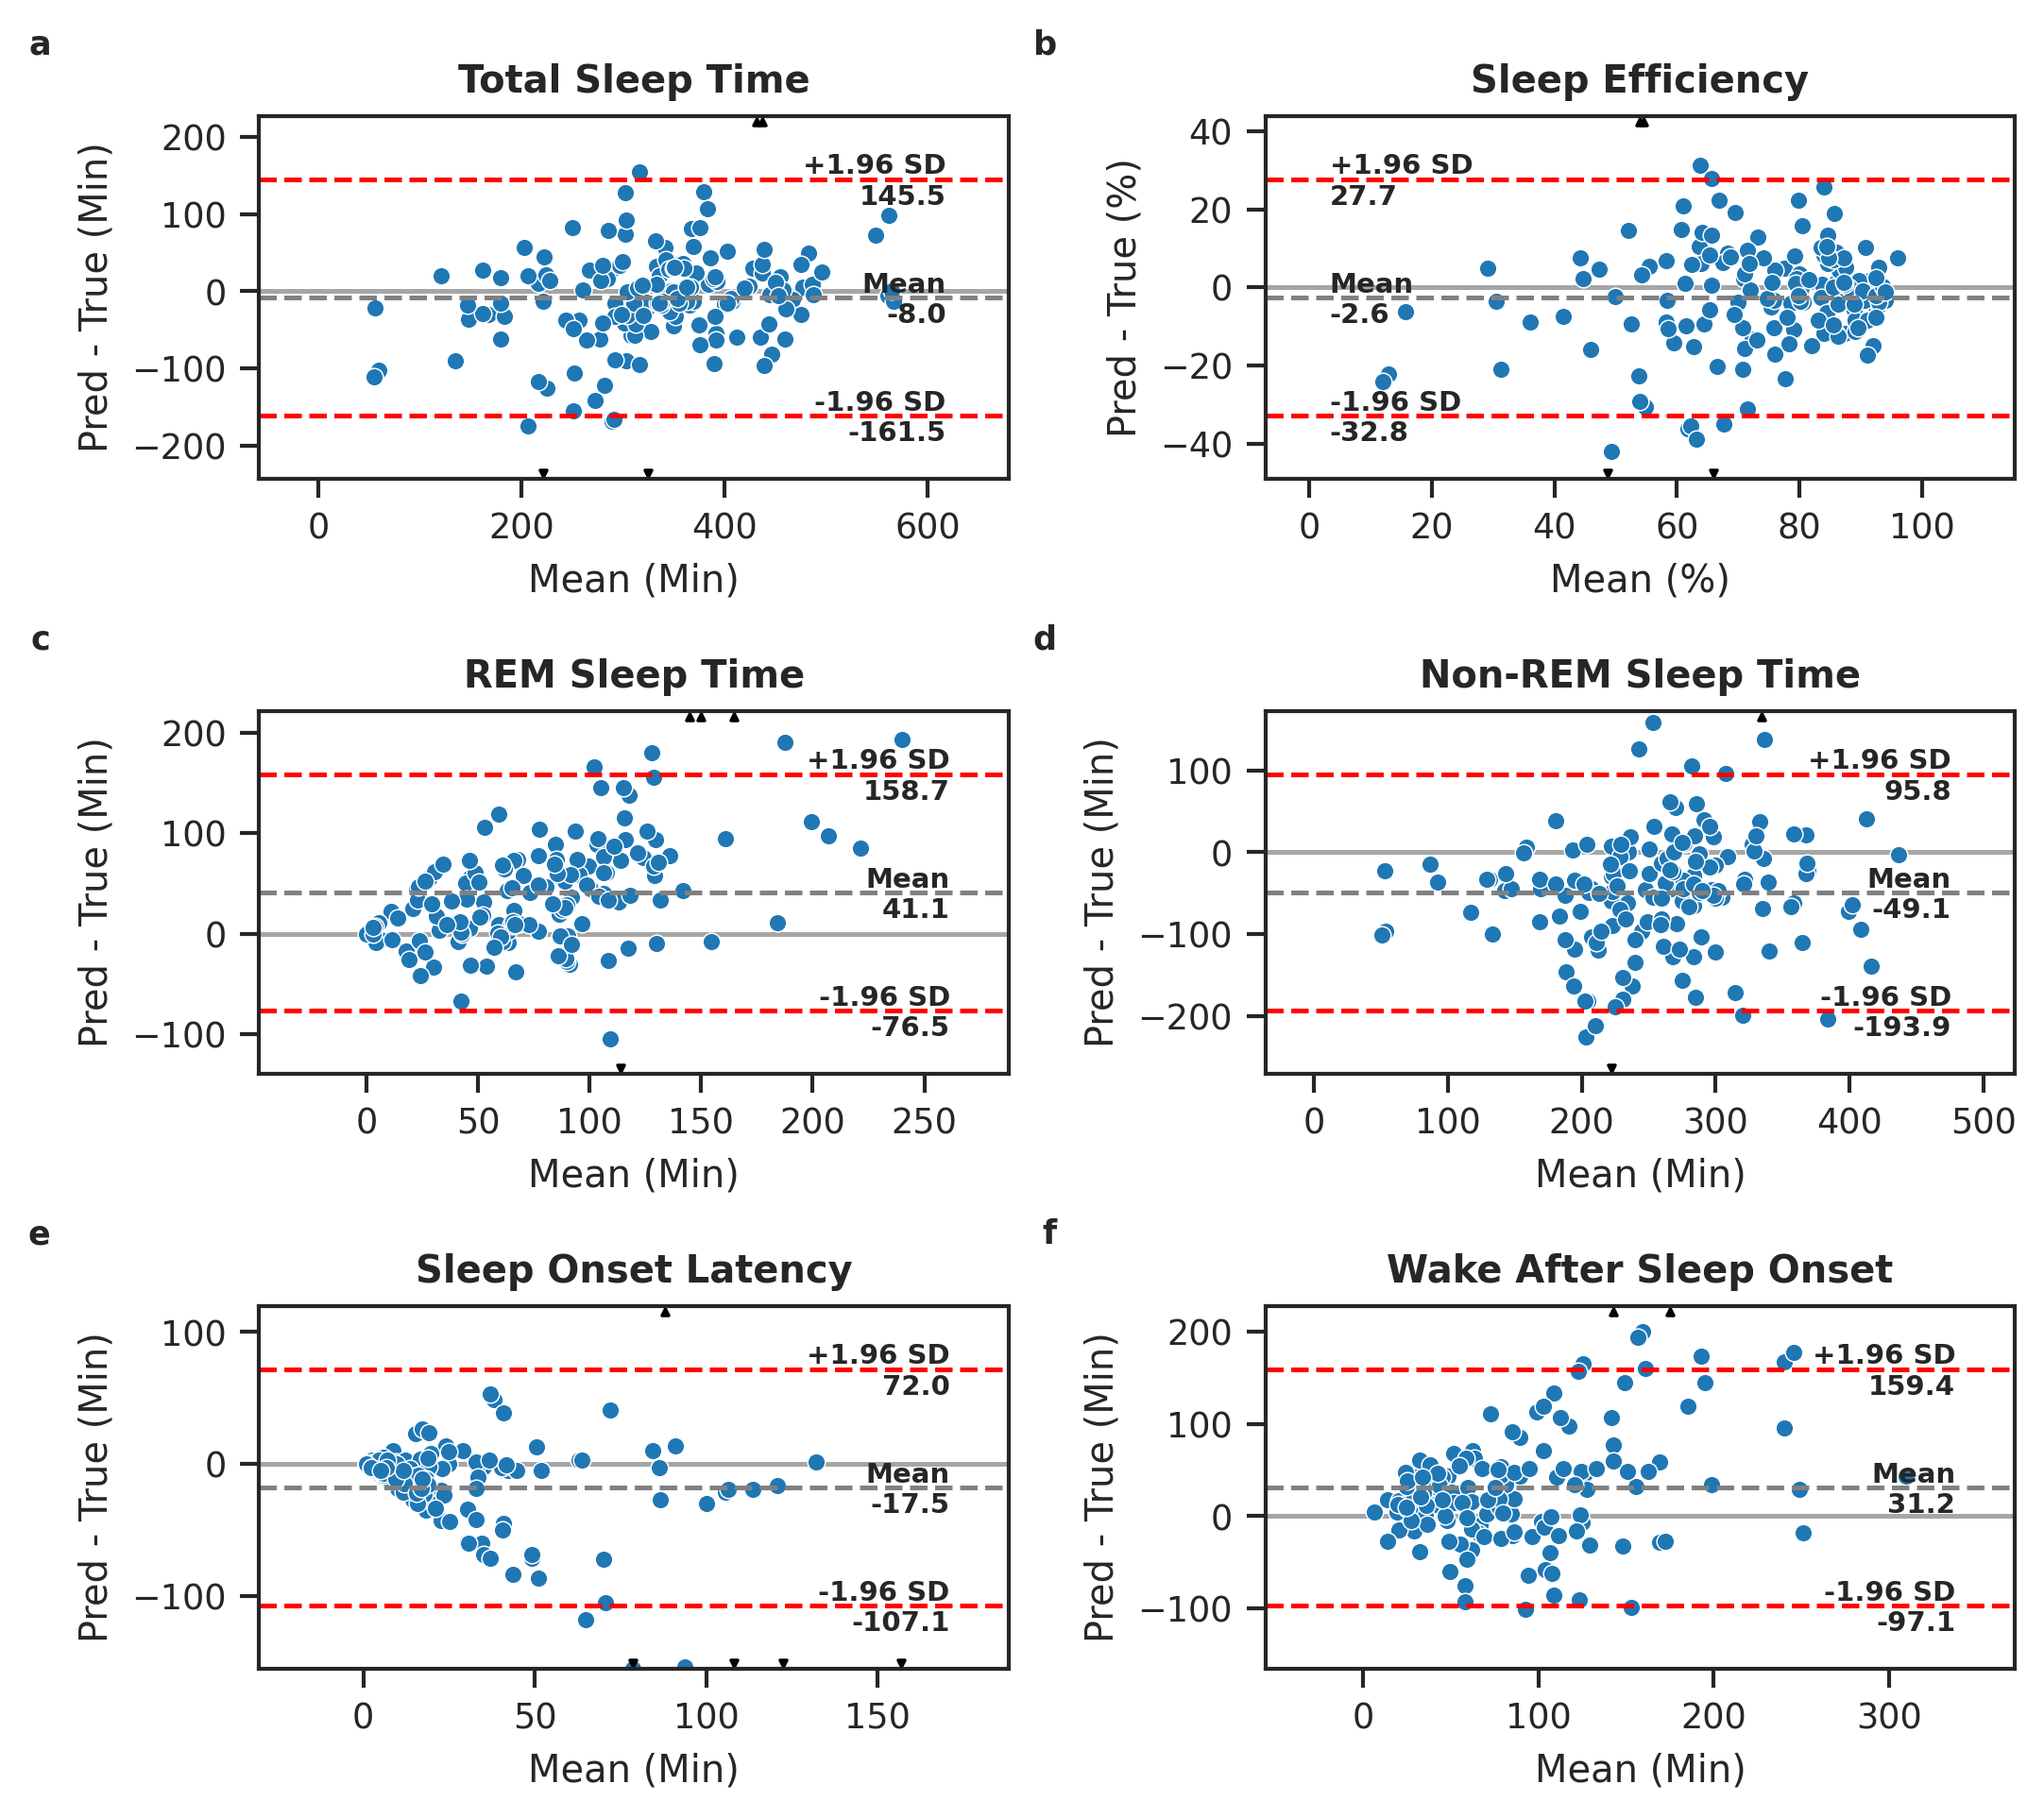

In [26]:
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

summary_diffs['dataset'] = dataset_i
summary_diffs['dataset'] = summary_diffs['dataset'].map(dset_map)

summary_diffs_linear = summary_diffs.loc[np.array(exp_i) == 'Linear']
summary_diffs_lstmc = summary_diffs.loc[np.array(exp_i) == 'LSTM-C']
summary_means_linear = summary_means.loc[np.array(exp_i) == 'Linear']
summary_means_lstmc = summary_means.loc[np.array(exp_i) == 'LSTM-C']
# dset_order = ['Health', 'Apple']

ba_summaries = []
errors = []
var_map = {
    'TST': 'Total Sleep Time',
    'SE': 'Sleep Efficiency',
    'REM': 'REM Sleep Time',
    'NREM': 'Non-REM Sleep Time',
    'LIGHT': 'Light Sleep Time',
    'DEEP': 'Deep Sleep Time',
    'WASO': 'Wake After Sleep Onset',
    'SOL': 'Sleep Onset Latency',
}
for means, diffs in [(summary_means_linear,summary_diffs_linear)]:#, (summary_means_lstmc,summary_diffs_lstmc)]:
    ba_summary = []
    errors_ = []
    layout = [
        ['TST', 'SE'],
        ['REM', 'NREM'],
        # ['Deep','Light'],
        ['SOL', 'WASO'],
        # ['Errors','Errors']
    ]
    fig, axes = plt.subplot_mosaic(layout,figsize=(7.1,6.3), dpi=300, layout = 'constrained')
    for i, (var, ax) in enumerate(axes.items()):
        if var == 'Errors':
            # Plot Summary metric errors
            # ax.set_title('Summary Metric Errors')
            # .drop(columns=['sol','se','waso'])
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="15%", pad=0.7)
            cax = sns.boxplot(
                diffs[['se', 'dataset']].melt(id_vars=['dataset']), 
                x='variable', y='value', hue='dataset', 
                saturation=0.75, ax=cax, showfliers=False, palette='Dark2', legend=False,
                hue_order=dset_order,
            )
            cax.set_ylabel('Error (%)')
            cax.set_xlabel('')

            melt_summary = diffs.drop(columns=['se']).melt(id_vars=['dataset'])
            melt_summary['variable'] = melt_summary['variable'].str.upper().replace(var_map)
            ax = sns.boxplot(
                melt_summary, x='variable', y='value', hue='dataset', 
                saturation=0.75, ax=ax, showfliers=False, palette='Dark2',
                hue_order=['Health', 'Apple']
            )
            ax.set_title('Error by Dataset', fontweight='bold')
            ax.set_ylabel('Error (Min)')
            ax.grid()
            ax.xaxis.set_label_position('top')
            ax.set_xlabel(' \n')
            ax.legend(
                title='', handletextpad = 0.3, columnspacing=0.6, 
                ncols=5, bbox_to_anchor=(0.33,1.),loc='lower left',
            )

        else:
            #Convert from epochs to minutes or fraction to %
            diff = diffs[var.lower()]
            mean = means[var.lower()]
            ax = sns.scatterplot(
                x=mean, y=diff,s=20, ax=ax, #hue=summary_diffs['dataset'], 
                # legend=(i==0), palette='Dark2',
                # hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
            )
            ax, ba_metrics = bland_altman(mean, diff, ax, annot_pos='left' if var == 'SE' else 'right')
            ax.set_title(f'{var_map[var]}',fontweight='bold')
            ax.set_xlabel('')
            if var == 'SE':
                ax.set_ylabel('Pred - True (%)')
                ax.set_xlabel('Mean (%)')
            else:
                ax.set_ylabel('Pred - True (Min)')
                ax.set_xlabel('Mean (Min)')
    
            ba_metrics.append(var)
            ba_summary.append(ba_metrics)

            mae = diff.abs()
            errors_.append([mae.mean(), mae.std(), np.sqrt(np.square(diff).mean()), var])
        # Add alphabetic ordering
        ax.annotate(
            f'{chr(97+i)}',
            xy=(-0.3, 1.2), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',fontweight='bold',
            fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
        )
    ba_summaries.append(ba_summary)
    errors.append(errors_)